<a href="https://colab.research.google.com/github/farrelrassya/IntroductionMachineLearningwithpython/blob/main/06.6_Advanced_Logistic_Regression_and_Extensions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 6 - Regresi Logistik Lanjutan dan Ekstensi (Advanced Logistic Regression and Extensions)

Notebook ini berisi hasil replikasi kode, latihan, dan penjelasan detail dari **Chapter 6 Advanced Logistic Regression and Extensions** pada buku *scikit-learn Cookbook, Third Edition*. Seluruh materi penjelasan teoretis telah diterjemahkan dan diperluas dalam **Bahasa Indonesia** secara mendalam.

In [1]:
# Memuat perpustakaan
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Muat kumpulan data
data = load_breast_cancer()
X = data.data
y = data.target

# Konversikan ke DataFrame untuk manipulasi yang lebih mudah (opsional)
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

# Pisahkan Datanya
X_train, X_test, y_train, y_test = train_test_split(df[data.feature_names], 
                                                    df['target'], 
                                                    test_size=0.2, 
                                                    random_state=2024)

### Bagaimana cara melakukannya
Seperti yang telah kita lihat sebelumnya (dan akan terus kita lihat), memuat model di scikit-learn semudah membuat instance Kelas dalam sebuah variabel dan membangunnya dari sana.

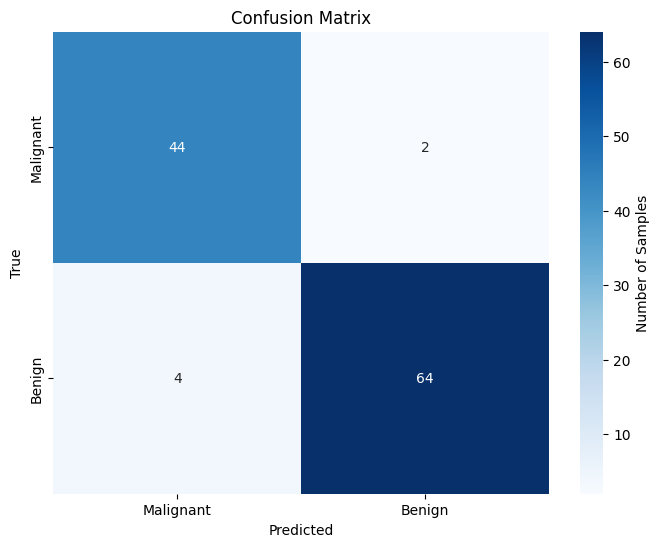

Accuracy: 0.95


Classification Report:


,precision,recall,f1-score,support
Malignant,0.917,0.957,0.936,46
Benign,0.970,0.941,0.955,68
accuracy,0.947,0.947,0.947,1
macro avg,0.943,0.949,0.946,114
weighted avg,0.948,0.947,0.948,114


In [2]:
# Buat Model Logistic Regression
model = LogisticRegression(max_iter=10000) # Increase max_iter if convergence issues occur 

# Latih Modelnya
model.fit(X_train, y_train)

# Buat Prediksi
y_pred = model.predict(X_test) 

# Evaluasi Kinerja
accuracy = accuracy_score(y_test, y_pred)

# Hasilkan dan plot Confusion Matrix
class_names = ['Malignant', 'Benign']
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names, 
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Dapatkan laporan klasifikasi sebagai kamus
report_dict = classification_report(y_test, y_pred,
                                  target_names=class_names, 
                                  output_dict=True)

# Buat DataFrame untuk visualisasi yang lebih baik
report_df = pd.DataFrame(report_dict).transpose()

# Gaya DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f'Accuracy: {accuracy:.2f}\n')
print("\nClassification Report:")
display(styled_df)

### Cara kerjanya
Logistic Regression beroperasi dengan memperkirakan probabilitas melalui kombinasi linier fitur masukan yang diubah oleh fungsi logistik. Koefisien yang diperoleh selama pelatihan menunjukkan seberapa besar kontribusi setiap fitur dalam memprediksi probabilitas untuk menjadi bagian dari kelas tertentu.

Batasan keputusan yang dibuat oleh Logistic Regression bersifat linier dalam hal “log-odds” tetapi dapat secara efektif memisahkan kelas dalam banyak skenario klasifikasi biner. Saat memvisualisasikan hasil, memplot probabilitas yang diprediksi terhadap hasil sebenarnya dapat memberikan wawasan tentang seberapa baik model membedakan kelas-kelas.

## Teknik Klasifikasi Multikelas

### Bersiap
Untuk memulai, sekali lagi kita akan menggunakan kumpulan data yang telah kita gunakan sebelumnya: kumpulan data Iris. Kumpulan data ini berisi tiga kelas sehingga sempurna untuk ilustrasi dasar klasifikasi multikelas.

In [3]:
# Muat perpustakaan
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import DecisionBoundaryDisplay
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Muat kumpulan data
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Pisahkan kumpulan data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

### Bagaimana cara melakukannya
Kami akan menerapkan Logistic Regression Satu-vs-Rest (OvR) dan Multinomial.

In [4]:
# Membuat dan melatih model Logistic Regression OvR
ovr_model = LogisticRegression(solver='liblinear')
ovr_model.fit(X_train, y_train)

# Membuat dan melatih model Logistic Regression Multinomial
multinomial_model = LogisticRegression(solver='lbfgs', max_iter = 1000)
multinomial_model.fit(X_train, y_train)

# Buat prediksi dengan model OvR
y_pred_ovr = ovr_model.predict(X_test)

# Buat prediksi dengan model Multinomial
y_pred_multinomial = multinomial_model.predict(X_test)

# Evaluasi model OvR
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)
report_ovr = pd.DataFrame(classification_report(y_test, y_pred_ovr, output_dict=True)).transpose()
print("One-vs-Rest (OvR) Logistic Regression:")

styled_ovr = (report_ovr
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_ovr)

# Evaluasi model Multinomial
accuracy_multinomial = accuracy_score(y_test, y_pred_multinomial)
report_multinomial = pd.DataFrame(classification_report(y_test, y_pred_multinomial, output_dict=True)).transpose()
print("Multinomial Logistic Regression:")

styled_multinomial = (report_multinomial
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_multinomial)

One-vs-Rest (OvR) Logistic Regression:


C:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1288: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.917,0.917,0.917,12
2,0.933,0.933,0.933,15
accuracy,0.956,0.956,0.956,1
macro avg,0.950,0.950,0.950,45
weighted avg,0.956,0.956,0.956,45


Multinomial Logistic Regression:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.846,0.917,0.880,12
2,0.929,0.867,0.897,15
accuracy,0.933,0.933,0.933,1
macro avg,0.925,0.928,0.926,45
weighted avg,0.935,0.933,0.934,45


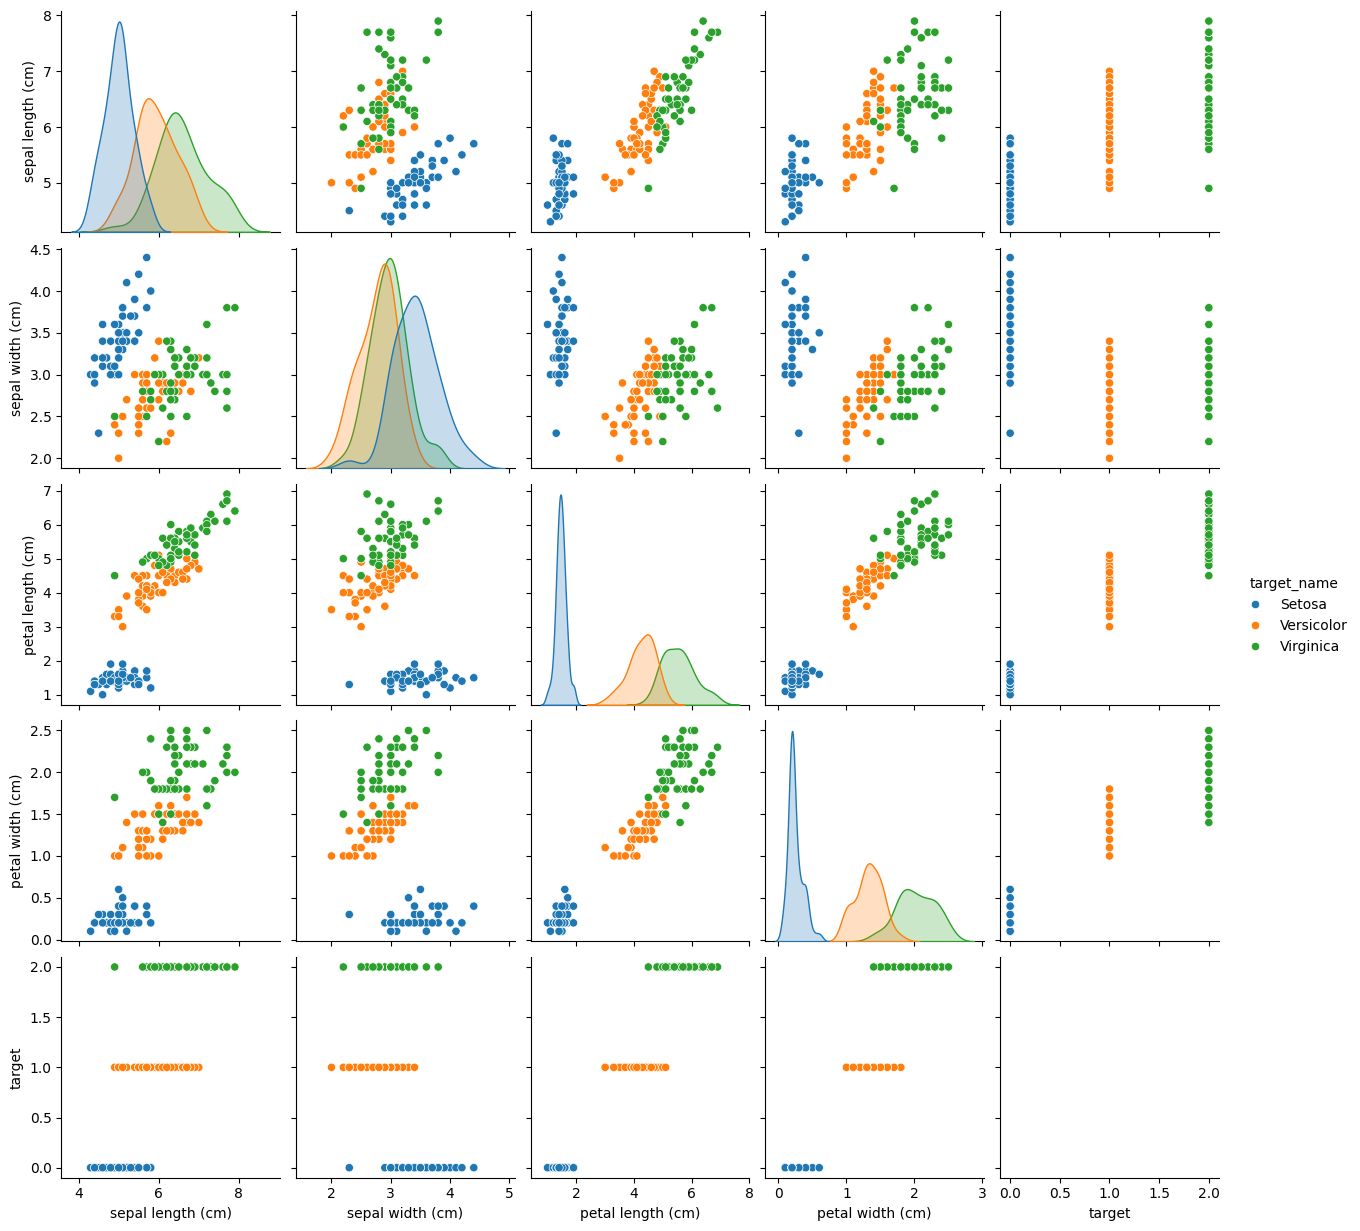

In [5]:
# Buat plot berpasangan untuk memvisualisasikan data
target_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
df['target_name'] = df['target'].map(target_names)
sns.pairplot(df, hue='target_name', diag_kind='kde')
plt.show()

### Cara kerjanya…
Kami menerapkan dua pendekatan berbeda di sini, OvR dan Multinomial, jadi mari kita bahas detailnya lebih detail.

* **Logistic Regression Satu-vs-Rest (OvR):** Satu-vs-Rest (juga dikenal sebagai “Satu-vs-Semua”) melibatkan pelatihan Classifier biner terpisah untuk setiap kelas. Untuk setiap Classifier, instance dari kelas tersebut diperlakukan sebagai kelas positif, dan instance dari semua kelas lainnya diperlakukan sebagai kelas negatif. Selama prediksi, Classifier dengan skor keyakinan tertinggi dipilih.

* **Logistic Regression Multinomial:** Logistic Regression multinomial, juga dikenal sebagai “Regresi SoftMax”, secara langsung memodelkan probabilitas setiap kelas menggunakan fungsi SoftMax. Ini memperkirakan beberapa koefisien regresi, satu untuk setiap kelas, dan mengoptimalkannya secara bersamaan. Pendekatan ini lebih cocok bila kelas-kelasnya saling eksklusif.

## Regularisasi dalam Logistic Regression 

### Bersiap
Sebelum menerapkan Logistic Regression reguler, pastikan kita telah menginstal pustaka Python yang diperlukan dan kumpulan data dimuat. Kami akan kembali menggunakan kumpulan data Kanker Payudara lagi.

In [6]:
# Muat perpustakaan
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# Muat kumpulan data
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Pisahkan kumpulan data dan skalakan
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Bagaimana cara melakukannya
Sekarang, mari kita terapkan model Logistic Regression teregulasi Ridge (L2) dan Lasso (L1).

In [7]:
# Membuat dan melatih model Logistic Regression teregulasi Ridge (L2).
ridge_model = LogisticRegression(penalty='l2', solver='liblinear', C=0.1)
ridge_model.fit(X_train, y_train)

# Membuat dan melatih model Logistic Regression teregulasi Lasso (L1).
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1)
lasso_model.fit(X_train, y_train)

# Buat prediksi dengan model Ridge
y_pred_ridge = ridge_model.predict(X_test)

# Buat prediksi dengan model Lasso
y_pred_lasso = lasso_model.predict(X_test)

# Evaluasi model Ridge
accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
report_ridge = pd.DataFrame(classification_report(y_test, y_pred_ridge, output_dict=True)).transpose()
print("Ridge (L2) Regularized Logistic Regression:")

styled_ridge = (report_ridge
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_ridge)

# Evaluasi model Lasso
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
report_lasso = pd.DataFrame(classification_report(y_test, y_pred_lasso, output_dict=True)).transpose()
print("Lasso (L1) Regularized Logistic Regression:")

styled_lasso = (report_lasso
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_lasso)


Ridge (L2) Regularized Logistic Regression:


,precision,recall,f1-score,support
0,0.985,0.970,0.977,67
1,0.981,0.990,0.986,104
accuracy,0.982,0.982,0.982,1
macro avg,0.983,0.980,0.982,171
weighted avg,0.982,0.982,0.982,171


Lasso (L1) Regularized Logistic Regression:


,precision,recall,f1-score,support
0,0.930,0.985,0.957,67
1,0.990,0.952,0.971,104
accuracy,0.965,0.965,0.965,1
macro avg,0.960,0.968,0.964,171
weighted avg,0.966,0.965,0.965,171


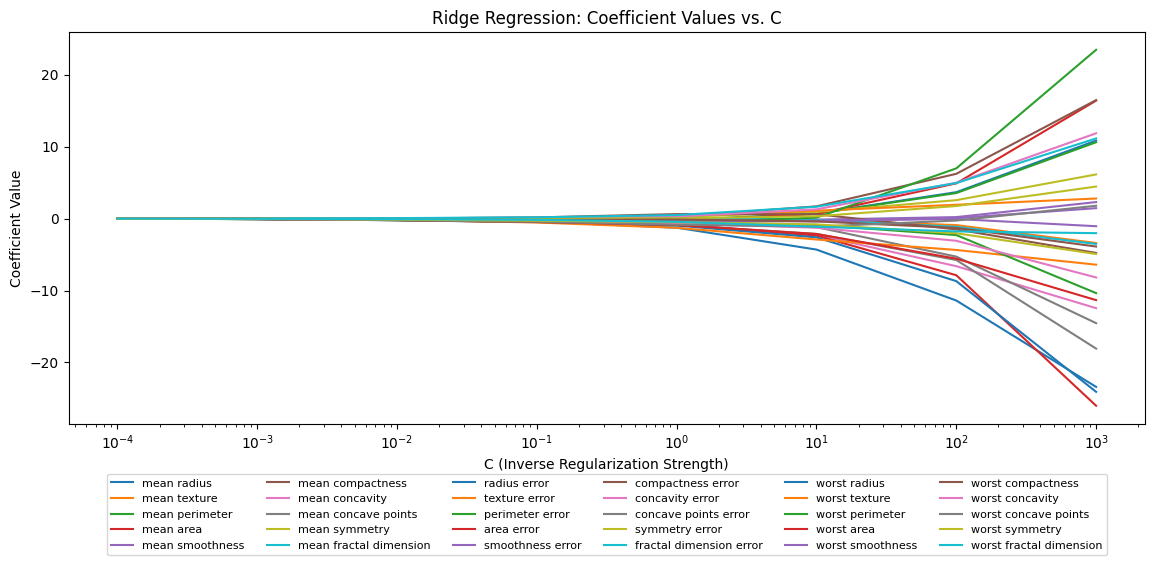

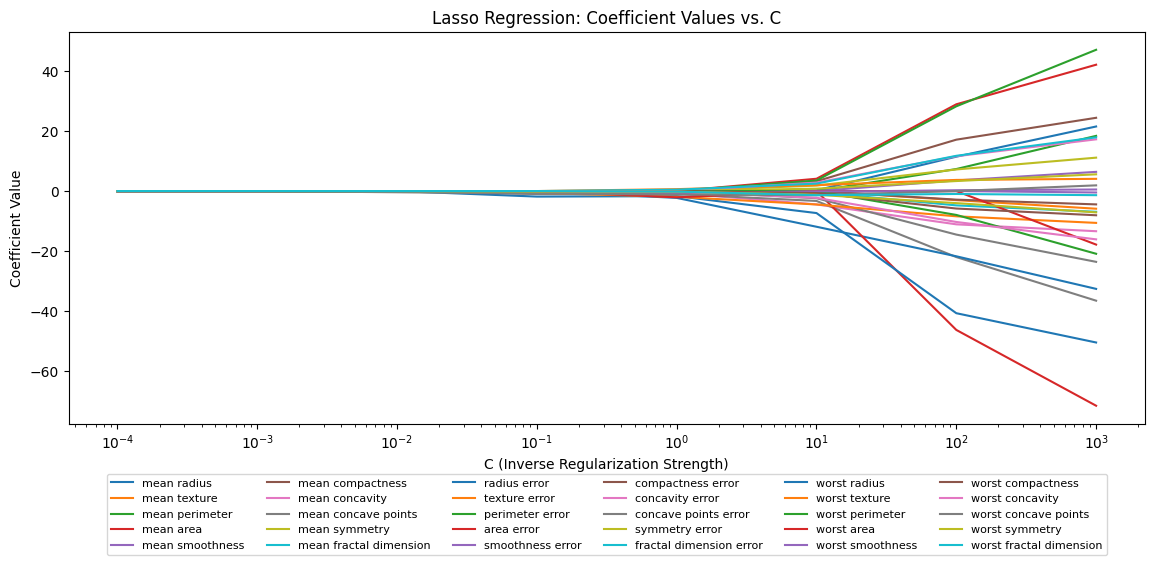

In [8]:
# Merencanakan koefisien untuk nilai C yang berbeda (Ridge)
C_values = np.array([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
coefs_ridge = []

for C in C_values:
    ridge_model = LogisticRegression(penalty='l2', solver='liblinear', C=C)
    ridge_model.fit(X_train, y_train)
    coefs_ridge.append(ridge_model.coef_[0])

plt.figure(figsize=(12, 6))
for i in range(X.shape[1]):
    plt.plot(C_values, [coef[i] for coef in coefs_ridge], label=feature_names[i])
plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Coefficient Values vs. C')
plt.legend(bbox_to_anchor=(0.5, -0.35), ncol=6, loc='lower center', fontsize=8)
plt.tight_layout()
plt.show()

# Merencanakan koefisien untuk nilai C yang berbeda (Lasso)
C_values = np.array([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
coefs_lasso = []

for C in C_values:
    lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=C)
    lasso_model.fit(X_train, y_train)
    coefs_lasso.append(lasso_model.coef_[0])

plt.figure(figsize=(12, 6))
for i in range(X.shape[1]):
    plt.plot(C_values, [coef[i] for coef in coefs_lasso], label=feature_names[i])
plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression: Coefficient Values vs. C')
plt.legend(bbox_to_anchor=(0.5, -0.35), ncol=6, loc='lower center', fontsize=8)
plt.tight_layout()
plt.show()


### Cara kerjanya

Regularisasi menambahkan istilah penalti pada fungsi kerugian, yang mencegah model menetapkan koefisien yang terlalu besar pada fitur. Hal ini membantu mencegah Overfitting, yaitu model berperforma baik pada data latih, namun buruk pada data yang tidak terlihat.
* **Regulerisasi Ridge (L2):** Menambahkan penalti yang sebanding dengan kuadrat besaran koefisien. Hal ini memperkecil koefisien menjadi nol tetapi jarang menjadikannya tepat nol.
* **Lasso (L1) Regularisasi:** Menambahkan penalti sebanding dengan nilai absolut koefisien. Hal ini dapat menyebabkan model menjadi renggang dengan mendorong beberapa koefisien hingga tepat nol, sehingga melakukan pemilihan fitur secara efektif.

Parameter C di LogisticRegression() mengontrol kebalikan dari kekuatan regularisasi; nilai yang lebih kecil menentukan regularisasi yang lebih kuat.

## Konsep Klasifikasi Multilabel

### Bersiap
Sebelum kita mulai menerapkan teknik klasifikasi multilabel, pastikan kita telah menginstal pustaka Python yang diperlukan dan kumpulan data dimuat. Kami akan membuat kumpulan data kami sendiri untuk contoh resep ini.

In [9]:
# Muat perpustakaan
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Muat kumpulan data
X, y = make_multilabel_classification(n_samples=1000, n_features=20, n_classes=5, n_labels=2, random_state=2024)
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = list(y)

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

### Bagaimana cara melakukannya...
Sekarang mari kita terapkan Logistic Regression multilabel menggunakan strategi One-vs-Rest (OvR).

In [10]:
# Karena kita memiliki banyak label, kita perlu melatih model terpisah untuk setiap label
models = []
y_pred_all = []

# Latih model untuk setiap label (kolom) di y
for i in range(y_train.shape[1]):
    # Buat dan latih model untuk label ini
    model = LogisticRegression(solver='liblinear')
    model.fit(X_train, y_train[:, i])
    models.append(model)
    
    # Buatlah prediksi untuk label ini
    y_pred_label = model.predict(X_test)
    y_pred_all.append(y_pred_label)

# Ubah daftar prediksi menjadi array dan ubah urutannya agar sesuai dengan format aslinya
y_pred = np.array(y_pred_all).T

# Evaluasi modelnya
accuracy = accuracy_score(y_test, y_pred)
report = pd.DataFrame(classification_report(y_test, y_pred, zero_division=1, output_dict=True)).transpose()
print("Classification Report:")

styled_report = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_report)


Classification Report:


,precision,recall,f1-score,support
0,0.808,0.813,0.811,166
1,0.801,0.845,0.823,181
2,0.674,0.333,0.446,93
3,0.750,0.176,0.286,34
4,0.575,0.477,0.522,88
micro avg,0.757,0.653,0.701,562
macro avg,0.722,0.529,0.577,562
weighted avg,0.744,0.653,0.677,562
samples avg,0.787,0.782,0.680,562



Label Statistics:
Total samples: 300

Label frequencies:
Label 0: 166 samples (55.3%)
Label 1: 181 samples (60.3%)
Label 2: 93 samples (31.0%)
Label 3: 34 samples (11.3%)
Label 4: 88 samples (29.3%)

Most common label combinations:
Combination [0 0 0 0 0]: 52 samples (17.3%)
Combination [0 1 0 0 0]: 34 samples (11.3%)
Combination [1 1 0 0 0]: 28 samples (9.3%)
Combination [1 1 1 0 0]: 25 samples (8.3%)
Combination [1 1 0 0 1]: 24 samples (8.0%)


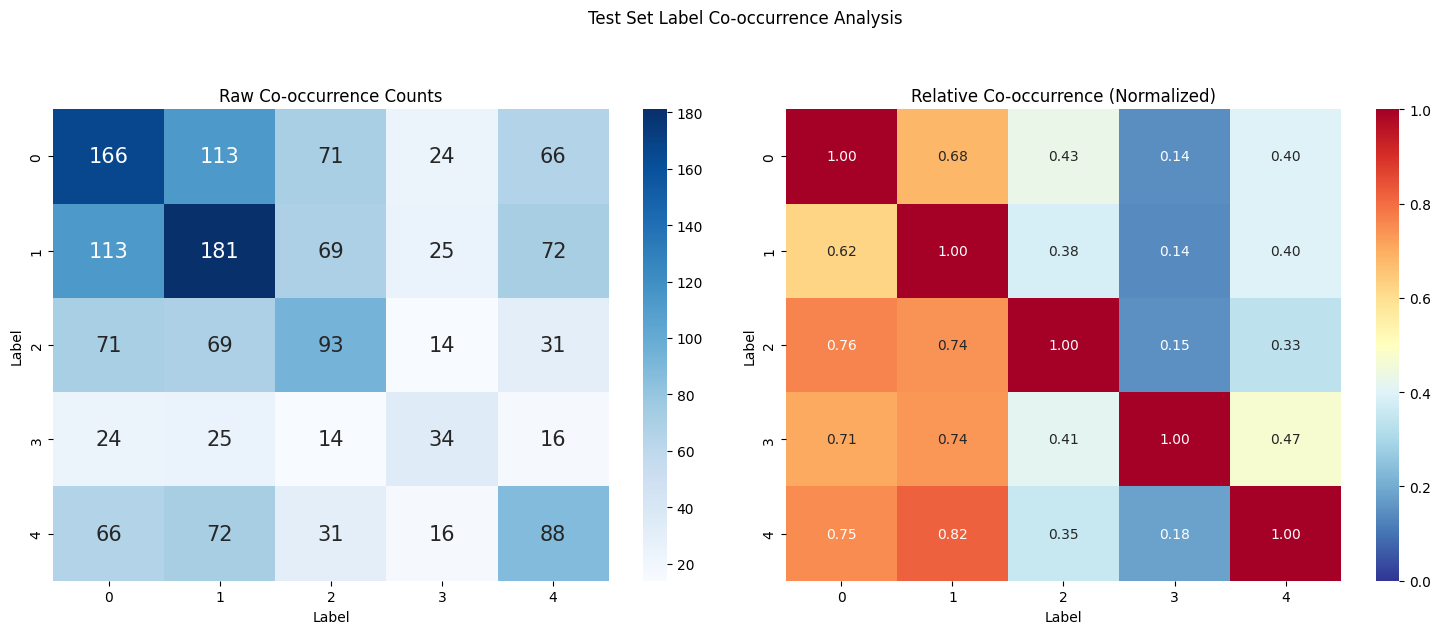

In [11]:
# Buat visualisasi kejadian bersama label yang mendetail
def plot_label_cooccurrence(y, title="Label Co-occurrence Analysis"):
    # Hitung jumlah kejadian bersama secara mentah
    cooccurrence = y.T @ y
    
    # Hitung kejadian bersama relatif (dinormalisasi dengan diagonal)
    # Ini menunjukkan berapa persentase label waktu i muncul dengan label j
    diag = np.diag(cooccurrence)
    relative_cooccurrence = cooccurrence / diag[:, None]
    
    # Buat gambar dengan dua subplot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot kejadian bersama yang mentah
    sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='Blues', 
                ax=ax1, annot_kws={"fontsize": 15})
    ax1.set_title('Raw Co-occurrence Counts')
    ax1.set_xlabel('Label')
    ax1.set_ylabel('Label')
    
    # Plot kejadian yang relatif bersamaan
    sns.heatmap(relative_cooccurrence, annot=True, fmt='.2f', 
                cmap='RdYlBu_r', ax=ax2, annot_kws={"fontsize": 10},
                vmin=0, vmax=1)
    ax2.set_title('Relative Co-occurrence (Normalized)')
    ax2.set_xlabel('Label')
    ax2.set_ylabel('Label')
    
    plt.suptitle(title, y=1.05)
    plt.tight_layout()
    
    # Cetak statistik tambahan
    print("\nLabel Statistics:")
    print(f"Total samples: {len(y)}")
    print("\nLabel frequencies:")
    for i in range(y.shape[1]):
        count = y[:, i].sum()
        percentage = count / len(y) * 100
        print(f"Label {i}: {count} samples ({percentage:.1f}%)")
    
    print("\nMost common label combinations:")
    # Dapatkan kombinasi unik dan jumlahnya
    unique_combinations = np.unique(y, axis=0, return_counts=True)
    sorted_idx = np.argsort(-unique_combinations[1])  # Sort by count (descending)
    for combo, count in zip(unique_combinations[0][sorted_idx][:5], 
                          unique_combinations[1][sorted_idx][:5]):
        percentage = count / len(y) * 100
        print(f"Combination {combo}: {count} samples ({percentage:.1f}%)")

# Gunakan fungsi pada data uji Anda
plot_label_cooccurrence(y_test, "Test Set Label Co-occurrence Analysis")

### Cara kerjanya…

Klasifikasi multilabel melibatkan prediksi beberapa label biner untuk setiap contoh. Dalam implementasi kami menggunakan Logistic Regression dengan strategi One-vs-Rest (OvR), kami melatih Classifier biner terpisah untuk setiap label kelas. Setiap Classifier belajar membedakan antara instance yang termasuk dalam kelasnya masing-masing dan yang tidak.

Fungsi make_multilabel_classification() menghasilkan kumpulan data sintetis yang cocok untuk masalah multilabel. Dataset yang dihasilkan terdiri dari fitur dan label terkait yang menunjukkan ada atau tidaknya setiap kelas.

Saat mengevaluasi performa model kami, metrik seperti skor akurasi dan laporan klasifikasi memberikan wawasan tentang seberapa baik model kami memprediksi beberapa label. Laporan klasifikasi mencakup presisi, perolehan, dan skor F1 untuk setiap label kelas, memungkinkan kami menilai kinerja secara komprehensif.

## Metrik Evaluasi Model 

### Bersiap
Saat ini Anda mungkin sudah memiliki gagasan bagus tentang apa yang perlu kita lakukan untuk mengevaluasi model kita menggunakan metode scikit-learn.

In [12]:
# Muat perpustakaan
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt

# Muat kumpulan data
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

### Bagaimana cara melakukannya…
Sekarang mari kita terapkan Logistic Regression dan evaluasi kinerjanya menggunakan berbagai metrik.

Accuracy 0.94
Precision 0.94
Recall 0.95
F1 Score 0.95
ROC AUC 0.99
Classification Report:


,precision,recall,f1-score,support
0,0.924,0.910,0.917,67
1,0.943,0.952,0.947,104
accuracy,0.936,0.936,0.936,1
macro avg,0.934,0.931,0.932,171
weighted avg,0.936,0.936,0.936,171


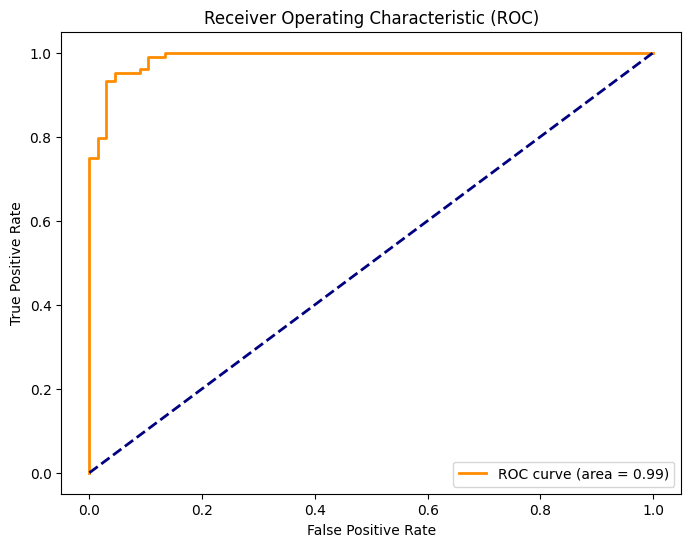

In [13]:
# Muat modelnya
model = LogisticRegression(solver='liblinear')

# Latih modelnya
model.fit(X_train, y_train)

# Buatlah prediksi
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Hitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
report = pd.DataFrame(classification_report(y_test, y_pred, zero_division=1, output_dict=True)).transpose()

# Cetak metriknya
print(f"Accuracy {accuracy:.2f}")
print(f"Precision {precision:.2f}")
print(f"Recall {recall:.2f}")
print(f"F1 Score {f1:.2f}")
print(f"ROC AUC {roc_auc:.2f}")
print("Classification Report:")

styled_report = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_report)

# Plot kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


## Latihan Praktis dengan Logistic Regression Tingkat Lanjut

### Latihan 1: Menerapkan Regresi Punggungan
Dalam latihan ini, kami akan membuat model Logistic Regression menggunakan kumpulan data Kanker Payudara, dengan menerapkan teknik regularisasi Lasso dan Ridge.

In [14]:
# Memuat perpustakaan
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Muat kumpulan data
data = load_breast_cancer()
X = data.data
y = data.target

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Membuat dan melatih model Logistic Regression yang diatur Lasso
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=10000, C=0.1)
lasso_model.fit(X_train, y_train)

# Buat prediksi dengan model Lasso
y_pred_lasso = lasso_model.predict(X_test)

# Evaluasi kinerja model Lasso
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
print(f"Lasso Model Accuracy: {accuracy_lasso:.2f}")

Lasso Model Accuracy: 0.95


### Latihan 2: Mengevaluasi Logistic Regression Multikelas
Dalam latihan ini, kita akan mengimplementasikan model Logistic Regression multinomial menggunakan dataset Iris.

In [15]:
# Muat perpustakaan
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Muat kumpulan data
iris = load_iris()
X = iris.data
y = iris.target

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Membuat dan melatih model Logistic Regression Multinomial
multinomial_model = LogisticRegression(solver='lbfgs', max_iter=1000)
multinomial_model.fit(X_train, y_train)

# Buat prediksi dengan model Multinomial
y_pred_multinomial = multinomial_model.predict(X_test)

# Evaluasi kinerja model Multinomial
accuracy_multinomial = accuracy_score(y_test, y_pred_multinomial)
print(f"Multinomial Model Accuracy: {accuracy_multinomial:.2f}")

Multinomial Model Accuracy: 0.93


### Latihan 3: Memvisualisasikan Hasil Logistic Regression
Dalam latihan ini, kami akan memvisualisasikan batasan keputusan model Logistic Regression yang dilatih pada kumpulan data sintetis.

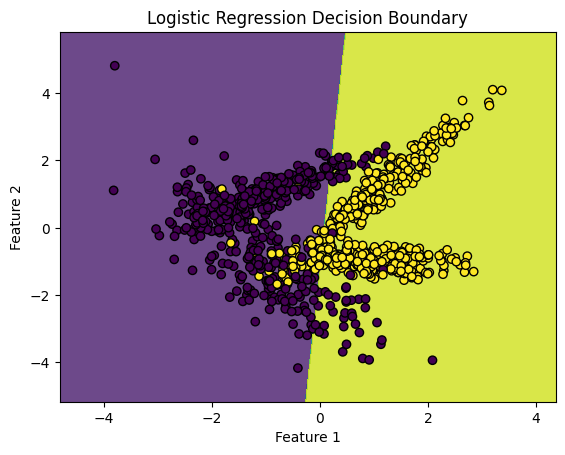

In [16]:
# Memuat perpustakaan untuk visualisasi dan pembuatan kumpulan data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Buat kumpulan data sintetis untuk klasifikasi biner
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_informative=2, n_redundant=0, random_state=2024)

# Pisahkan datanya
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Membuat dan melatih model Logistic Regression
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

# Buat grid mesh untuk merencanakan batas-batas keputusan
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Memprediksi probabilitas kelas di seluruh grid
Z = logistic_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Batasan keputusan plot
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Ringkasan dan Pandangan (Summary and Outlook)

#### 1. Ringkasan Bab
Dalam bab ini, kita telah memperdalam model Regresi Logistik untuk tugas klasifikasi:
* **Klasifikasi Multikelas:** Menggunakan strategi One-vs-Rest (OVR) dan One-vs-One (OVO) untuk menangani dataset yang memiliki lebih dari dua kelas.
* **Regularisasi pada Klasifikasi:** Menerapkan penalti L1 dan L2 pada fungsi loss regresi logistik untuk mengontrol kompleksitas model.
* **Klasifikasi Multilabel:** Menggunakan pembungkus (`MultiOutputClassifier`) untuk memprediksi beberapa label target sekaligus bagi satu sampel input.

#### 2. Pandangan ke Depan
Regresi Logistik adalah standar industri untuk klasifikasi probabilistik. Namun, untuk dataset dengan batas keputusan yang non-linier dan kompleks, kita memerlukan model batas margin maksimum. Di **Bab 7**, kita akan mempelajari Support Vector Machine (SVM) yang dapat menangani data non-linier menggunakan trik kernel.